# Bus Demand Prediction Using Big Data Analytics and PySpark

# Environmental Setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier
)

from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

import matplotlib.pyplot as plt
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
spark = SparkSession.builder \
    .appName("UK Bus Big Data Analytics") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 3.5.8


# Data Collection

In [3]:
stops = spark.read.csv(
    r"C:\bigdata\stops.txt",
    header=True,
    inferSchema=True
)
routes = spark.read.csv(
    r"C:\bigdata\routes.txt",
    header=True,
    inferSchema=True
)
trips = spark.read.csv(
    r"C:\bigdata\trips.txt",
    header=True,
    inferSchema=True
)
stop_times = spark.read.csv(
    r"C:\bigdata\stop_times.txt",
    header=True,
    inferSchema=True
)
agency = spark.read.csv(
    r"C:\bigdata\agency.txt",
    header=True,
    inferSchema=True
)
print("Datasets loaded successfully.")

Datasets loaded successfully.


In [4]:
fraction = 500000 / stop_times.count()

stop_times = stop_times.sample(
    withReplacement=False,
    fraction=fraction,
    seed=42
)

print("Reduced Stop Times Dataset:", stop_times.count())

Reduced Stop Times Dataset: 500911


# Data Exploration

In [5]:
print("Stops      :", stops.count())
print("Routes     :", routes.count())
print("Trips      :", trips.count())
print("Stop Times :", stop_times.count())
print("Agency     :", agency.count())

Stops      : 310270
Routes     : 12808
Trips      : 1460615
Stop Times : 500911
Agency     : 633


In [6]:
print("Stops Dataset")
stops.show(5, truncate=False)

print("\nRoutes Dataset")
routes.show(5, truncate=False)

print("\nTrips Dataset")
trips.show(5, truncate=False)

print("\nStop Times Dataset")
stop_times.show(5, truncate=False)

print("\nAgency Dataset")
agency.show(5, truncate=False)

Stops Dataset
+------------+---------+----------------+-----------------+--------------------+-------------------+-------------+--------------+-------------+
|stop_id     |stop_code|stop_name       |stop_lat         |stop_lon            |wheelchair_boarding|location_type|parent_station|platform_code|
+------------+---------+----------------+-----------------+--------------------+-------------------+-------------+--------------+-------------+
|0500HFENS002|CMBDPADW |Chequer Street  |52.29866634479469|-0.07298550827900555|0                  |0            |NULL          |NULL         |
|43000686302 |nwmjdpjd |Forge Road      |52.56891         |-2.04445            |0                  |0            |NULL          |NULL         |
|2000G503137 |wocdatma |Lydiate Ash Road|52.375432        |-2.045078           |0                  |0            |NULL          |NULL         |
|5510AWA12874|breapmg  |Iron Bridge     |51.614486576     |-3.662408445        |0                  |0            |NULL    

In [7]:
print("Stops Schema")
stops.printSchema()

print("\nRoutes Schema")
routes.printSchema()

print("\nTrips Schema")
trips.printSchema()

print("\nStop Times Schema")
stop_times.printSchema()

print("\nAgency Schema")
agency.printSchema()

Stops Schema
root
 |-- stop_id: string (nullable = true)
 |-- stop_code: string (nullable = true)
 |-- stop_name: string (nullable = true)
 |-- stop_lat: double (nullable = true)
 |-- stop_lon: double (nullable = true)
 |-- wheelchair_boarding: integer (nullable = true)
 |-- location_type: integer (nullable = true)
 |-- parent_station: string (nullable = true)
 |-- platform_code: string (nullable = true)


Routes Schema
root
 |-- route_id: integer (nullable = true)
 |-- agency_id: string (nullable = true)
 |-- route_short_name: string (nullable = true)
 |-- route_long_name: string (nullable = true)
 |-- route_type: integer (nullable = true)


Trips Schema
root
 |-- route_id: integer (nullable = true)
 |-- service_id: integer (nullable = true)
 |-- trip_id: string (nullable = true)
 |-- trip_headsign: string (nullable = true)
 |-- direction_id: integer (nullable = true)
 |-- block_id: string (nullable = true)
 |-- shape_id: string (nullable = true)
 |-- wheelchair_accessible: integer (n

# Checking Missing Values

In [8]:
datasets = {
    "Stops": stops,
    "Routes": routes,
    "Trips": trips,
    "Stop Times": stop_times,
    "Agency": agency
}

for name, df in datasets.items():

    print(f"\n{name} Missing Values")

    df.select([
        sum(col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ]).show()


Stops Missing Values
+-------+---------+---------+--------+--------+-------------------+-------------+--------------+-------------+
|stop_id|stop_code|stop_name|stop_lat|stop_lon|wheelchair_boarding|location_type|parent_station|platform_code|
+-------+---------+---------+--------+--------+-------------------+-------------+--------------+-------------+
|      0|     5687|        0|       0|       0|                  0|            0|        306953|       307329|
+-------+---------+---------+--------+--------+-------------------+-------------+--------------+-------------+


Routes Missing Values
+--------+---------+----------------+---------------+----------+
|route_id|agency_id|route_short_name|route_long_name|route_type|
+--------+---------+----------------+---------------+----------+
|       0|        0|               0|          12808|         0|
+--------+---------+----------------+---------------+----------+


Trips Missing Values
+--------+----------+-------+-------------+--------

In [9]:
stops = stops.dropDuplicates()
routes = routes.dropDuplicates()
trips = trips.dropDuplicates()
stop_times = stop_times.dropDuplicates()
agency = agency.dropDuplicates()

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [10]:
print("Duplicate Records After Cleaning\n")

print(f"Stops      : {stops.count() - stops.dropDuplicates().count()}")
print(f"Routes     : {routes.count() - routes.dropDuplicates().count()}")
print(f"Trips      : {trips.count() - trips.dropDuplicates().count()}")
print(f"Stop Times : {stop_times.count() - stop_times.dropDuplicates().count()}")
print(f"Agency     : {agency.count() - agency.dropDuplicates().count()}")

Duplicate Records After Cleaning

Stops      : 0
Routes     : 0
Trips      : 0
Stop Times : 0
Agency     : 0


# Data Preprocessing

In [11]:
# Merge Trips with Routes
data = trips.join(routes, on="route_id", how="inner")

# Merge with Stop Times
data = data.join(stop_times, on="trip_id", how="inner")

# Merge with Stops
data = data.join(stops, on="stop_id", how="inner")

print("Merged dataset created successfully.")

# Display first five records
data.show(5, truncate=False)

Merged dataset created successfully.
+------------+------------------------------------------+--------+----------+-------------------------------+------------+----------------------------------------+------------------------------------+---------------------+--------------------+---------+----------------+---------------+----------+------------+--------------+-------------+-------------+-----------+-------------+-------------------+---------+---------+------------------------+--------+---------+-------------------+-------------+--------------+-------------+
|stop_id     |trip_id                                   |route_id|service_id|trip_headsign                  |direction_id|block_id                                |shape_id                            |wheelchair_accessible|vehicle_journey_code|agency_id|route_short_name|route_long_name|route_type|arrival_time|departure_time|stop_sequence|stop_headsign|pickup_type|drop_off_type|shape_dist_traveled|timepoint|stop_code|stop_name        

In [12]:
data.printSchema()

root
 |-- stop_id: string (nullable = true)
 |-- trip_id: string (nullable = true)
 |-- route_id: integer (nullable = true)
 |-- service_id: integer (nullable = true)
 |-- trip_headsign: string (nullable = true)
 |-- direction_id: integer (nullable = true)
 |-- block_id: string (nullable = true)
 |-- shape_id: string (nullable = true)
 |-- wheelchair_accessible: integer (nullable = true)
 |-- vehicle_journey_code: string (nullable = true)
 |-- agency_id: string (nullable = true)
 |-- route_short_name: string (nullable = true)
 |-- route_long_name: string (nullable = true)
 |-- route_type: integer (nullable = true)
 |-- arrival_time: string (nullable = true)
 |-- departure_time: string (nullable = true)
 |-- stop_sequence: integer (nullable = true)
 |-- stop_headsign: string (nullable = true)
 |-- pickup_type: integer (nullable = true)
 |-- drop_off_type: integer (nullable = true)
 |-- shape_dist_traveled: string (nullable = true)
 |-- timepoint: integer (nullable = true)
 |-- stop_code

In [13]:
print("Total Records in Merged Dataset:", data.count())

Total Records in Merged Dataset: 500911


# Feature Engineering

In [14]:
from pyspark.sql.functions import split, col

data = data.withColumn(
    "departure_hour",
    split(col("departure_time"), ":").getItem(0).cast("integer")
)

data.select(
    "departure_time",
    "departure_hour"
).show(10, truncate=False)

+--------------+--------------+
|departure_time|departure_hour|
+--------------+--------------+
|22:35:00      |22            |
|13:02:00      |13            |
|09:18:00      |9             |
|12:37:00      |12            |
|09:16:00      |9             |
|00:27:55      |0             |
|10:53:00      |10            |
|11:12:00      |11            |
|17:36:35      |17            |
|17:57:16      |17            |
+--------------+--------------+
only showing top 10 rows



In [15]:
from pyspark.sql.functions import count

stop_frequency = (
    data.groupBy("stop_id")
        .agg(count("*").alias("stop_frequency"))
)

data = data.join(
    stop_frequency,
    on="stop_id",
    how="left"
)

print(
    "Average Stop Frequency:",
    data.selectExpr("avg(stop_frequency)").first()[0]
)

data.select(
    "stop_id",
    "stop_frequency"
).show(5)

Average Stop Frequency: 8.895534336439008
+------------+--------------+
|     stop_id|stop_frequency|
+------------+--------------+
|0100BRA10458|            11|
|040000005862|             1|
|149000006309|            12|
|1980SN120501|            22|
|1990PH130463|            31|
+------------+--------------+
only showing top 5 rows



In [16]:
from pyspark.sql.functions import col, when, avg

# Calculate average stop frequency
average_frequency = stop_frequency.select(
    avg("stop_frequency")
).collect()[0][0]

print("Average Stop Frequency:", average_frequency)

# Create target label
# 1 = High Demand
# 0 = Normal Demand

data = data.withColumn(
    "label",
    when(
        col("stop_frequency") >= average_frequency,
        1
    ).otherwise(0)
)

# Display label distribution
data.groupBy("label").count().show()

Average Stop Frequency: 3.30640870776319
+-----+------+
|label| count|
+-----+------+
|    1|322532|
|    0|178379|
+-----+------+



In [17]:
ml_data = data.select(
    "departure_hour",
    "stop_lat",
    "stop_lon",
    "direction_id",
    "route_type",
    "label"
)

print("Final ML Dataset:")

ml_data.printSchema()

ml_data.show(5, truncate=False)

Final ML Dataset:
root
 |-- departure_hour: integer (nullable = true)
 |-- stop_lat: double (nullable = true)
 |-- stop_lon: double (nullable = true)
 |-- direction_id: integer (nullable = true)
 |-- route_type: integer (nullable = true)
 |-- label: integer (nullable = false)

+--------------+---------+---------+------------+----------+-----+
|departure_hour|stop_lat |stop_lon |direction_id|route_type|label|
+--------------+---------+---------+------------+----------+-----+
|20            |51.45864 |-2.55828 |0           |3         |1    |
|13            |51.598842|-0.703749|1           |3         |0    |
|19            |50.855349|-0.163037|0           |3         |1    |
|14            |50.91081 |-1.41984 |1           |3         |1    |
|16            |50.79562 |-1.10306 |1           |3         |1    |
+--------------+---------+---------+------------+----------+-----+
only showing top 5 rows



In [18]:
data.cache()

print("Dataset cached successfully.")
print("Is Cached:", data.is_cached)

Dataset cached successfully.
Is Cached: True


In [19]:
print("Current Number of Partitions:")

print(data.rdd.getNumPartitions())

Current Number of Partitions:
8


In [20]:
data = data.repartition(8)

print("New Number of Partitions:")

print(data.rdd.getNumPartitions())

New Number of Partitions:
8


# Machine Learning

In [21]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "departure_hour",
        "stop_lat",
        "stop_lon",
        "direction_id",
        "route_type"
    ],
    outputCol="features"
)

ml_data = assembler.transform(ml_data)

ml_data.select(
    "departure_hour",
    "stop_lat",
    "stop_lon",
    "direction_id",
    "route_type",
    "features",
    "label"
).show(10, truncate=False)

+--------------+--------+---------+------------+----------+---------------------------------+-----+
|departure_hour|stop_lat|stop_lon |direction_id|route_type|features                         |label|
+--------------+--------+---------+------------+----------+---------------------------------+-----+
|9             |52.51768|-0.277821|0           |3         |[9.0,52.51768,-0.277821,0.0,3.0] |0    |
|15            |52.51768|-0.277821|0           |3         |[15.0,52.51768,-0.277821,0.0,3.0]|0    |
|15            |51.41306|-2.61187 |0           |3         |[15.0,51.41306,-2.61187,0.0,3.0] |0    |
|5             |51.41306|-2.61187 |0           |3         |[5.0,51.41306,-2.61187,0.0,3.0]  |0    |
|20            |51.41306|-2.61187 |0           |3         |[20.0,51.41306,-2.61187,0.0,3.0] |0    |
|11            |51.41113|-2.61908 |1           |3         |[11.0,51.41113,-2.61908,1.0,3.0] |0    |
|7             |51.44305|-2.62471 |0           |3         |[7.0,51.44305,-2.62471,0.0,3.0]  |0    |


In [22]:
train_data, test_data = ml_data.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Records:", train_data.count())
print("Testing Records :", test_data.count())

Training Records: 400840
Testing Records : 100071


In [23]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100
)

lr_model = lr.fit(train_data)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [24]:
lr_predictions = lr_model.transform(test_data)

lr_predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |1.0       |[0.2286811403052212,0.7713188596947789] |
|1    |1.0       |[0.23885983076333805,0.761140169236662] |
|1    |1.0       |[0.240277238110789,0.7597227618892111]  |
|0    |1.0       |[0.24321613747242443,0.7567838625275756]|
|1    |1.0       |[0.2618078213854788,0.7381921786145211] |
|1    |1.0       |[0.260975561013329,0.7390244389866709]  |
|1    |1.0       |[0.24632023247834017,0.7536797675216598]|
|1    |1.0       |[0.25116479320345747,0.7488352067965425]|
|1    |1.0       |[0.24663090963565176,0.7533690903643482]|
|1    |1.0       |[0.25143205565848314,0.7485679443415169]|
+-----+----------+----------------------------------------+
only showing top 10 rows



In [25]:
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

lr_accuracy = accuracy_evaluator.evaluate(lr_predictions)
lr_precision = precision_evaluator.evaluate(lr_predictions)
lr_recall = recall_evaluator.evaluate(lr_predictions)
lr_f1 = f1_evaluator.evaluate(lr_predictions)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Performance
--------------------------------
Accuracy : 0.6541555495598126
Precision: 0.6261040184247499
Recall   : 0.6541555495598125
F1 Score : 0.6021487895441218


In [26]:
lr_predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 7444|
|    0|       1.0|28390|
|    1|       0.0| 6219|
|    1|       1.0|58018|
+-----+----------+-----+



In [27]:
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=10,
    seed=42
)

dt_model = dt.fit(train_data)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [28]:
dt_predictions = dt_model.transform(test_data)

dt_predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+---------------------------------------+
|label|prediction|probability                            |
+-----+----------+---------------------------------------+
|1    |1.0       |[0.0265002696248363,0.9734997303751637]|
|1    |1.0       |[0.0265002696248363,0.9734997303751637]|
|1    |1.0       |[0.0265002696248363,0.9734997303751637]|
|0    |1.0       |[0.1645818692902319,0.8354181307097681]|
|1    |1.0       |[0.1645818692902319,0.8354181307097681]|
|1    |1.0       |[0.1645818692902319,0.8354181307097681]|
|1    |1.0       |[0.1645818692902319,0.8354181307097681]|
|1    |1.0       |[0.1645818692902319,0.8354181307097681]|
|1    |1.0       |[0.1645818692902319,0.8354181307097681]|
|1    |1.0       |[0.1645818692902319,0.8354181307097681]|
+-----+----------+---------------------------------------+
only showing top 10 rows



In [29]:
dt_accuracy = accuracy_evaluator.evaluate(dt_predictions)

dt_precision = precision_evaluator.evaluate(dt_predictions)

dt_recall = recall_evaluator.evaluate(dt_predictions)

dt_f1 = f1_evaluator.evaluate(dt_predictions)

print("Decision Tree Performance")
print("--------------------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree Performance
--------------------------------
Accuracy : 0.7622488033496218
Precision: 0.7589392693969412
Recall   : 0.7622488033496218
F1 Score : 0.7599820737996763


In [30]:
dt_predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|22555|
|    0|       1.0|13279|
|    1|       0.0|10513|
|    1|       1.0|53724|
+-----+----------+-----+



In [31]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(train_data)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [32]:
rf_predictions = rf_model.transform(test_data)

rf_predictions.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|1    |1.0       |[0.041708396722093484,0.9582916032779064]|
|1    |1.0       |[0.04067391199644893,0.9593260880035511] |
|1    |1.0       |[0.047644093601186564,0.9523559063988134]|
|0    |1.0       |[0.15229086578281906,0.8477091342171809] |
|1    |1.0       |[0.15599448512236394,0.8440055148776361] |
|1    |1.0       |[0.15599448512236394,0.8440055148776361] |
|1    |1.0       |[0.24939225420405922,0.7506077457959407] |
|1    |1.0       |[0.13052916003805298,0.8694708399619471] |
|1    |1.0       |[0.12852630958222672,0.8714736904177733] |
|1    |1.0       |[0.14234901750684037,0.8576509824931595] |
+-----+----------+-----------------------------------------+
only showing top 10 rows



In [33]:
rf_accuracy = accuracy_evaluator.evaluate(rf_predictions)

rf_precision = precision_evaluator.evaluate(rf_predictions)

rf_recall = recall_evaluator.evaluate(rf_predictions)

rf_f1 = f1_evaluator.evaluate(rf_predictions)

print("Random Forest Performance")
print("--------------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Performance
--------------------------------
Accuracy : 0.7608697824544574
Precision: 0.7687186731578336
Recall   : 0.7608697824544574
F1 Score : 0.7634479672176737


In [34]:
rf_predictions.groupBy(
    "label",
    "prediction"
).count().orderBy(
    "label",
    "prediction"
).show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|25969|
|    0|       1.0| 9865|
|    1|       0.0|14065|
|    1|       1.0|50172|
+-----+----------+-----+



# Model Evaluation

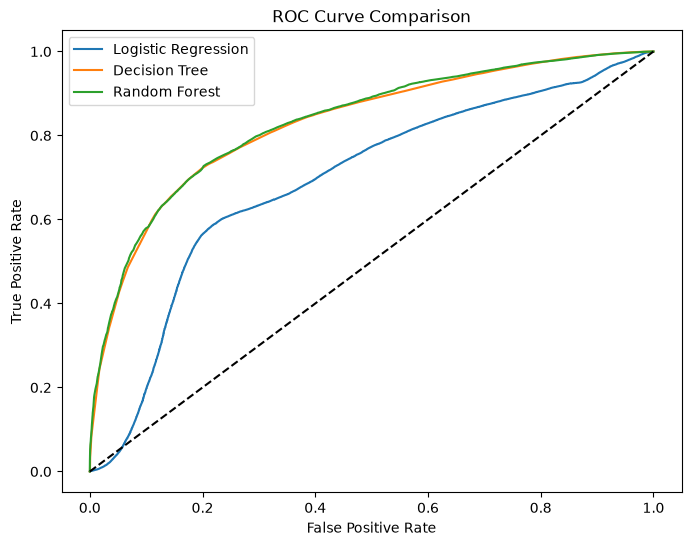

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def create_roc_dataframe(predictions):

    roc_df = predictions.select(
        "label",
        "probability"
    ).toPandas()

    roc_df["probability"] = roc_df["probability"].apply(
        lambda x: float(x[1])
    )

    return roc_df


lr_roc_data = create_roc_dataframe(lr_predictions)
dt_roc_data = create_roc_dataframe(dt_predictions)
rf_roc_data = create_roc_dataframe(rf_predictions)


lr_fpr, lr_tpr, _ = roc_curve(
    lr_roc_data["label"],
    lr_roc_data["probability"]
)

dt_fpr, dt_tpr, _ = roc_curve(
    dt_roc_data["label"],
    dt_roc_data["probability"]
)

rf_fpr, rf_tpr, _ = roc_curve(
    rf_roc_data["label"],
    rf_roc_data["probability"]
)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label="Logistic Regression"
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label="Decision Tree"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [36]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

print("ROC-AUC Scores")
print("--------------------------------")

print(
    "Logistic Regression:",
    auc_evaluator.evaluate(lr_predictions)
)

print(
    "Decision Tree:",
    auc_evaluator.evaluate(dt_predictions)
)

print(
    "Random Forest:",
    auc_evaluator.evaluate(rf_predictions)
)

ROC-AUC Scores
--------------------------------
Logistic Regression: 0.6911184191465715
Decision Tree: 0.7529170906327185
Random Forest: 0.8318385550996977


In [37]:
import pandas as pd

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision":[
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall":[
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score":[
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.654156,0.626104,0.654156,0.602149
1,Decision Tree,0.762249,0.758939,0.762249,0.759982
2,Random Forest,0.760870,0.768719,0.760870,0.763448


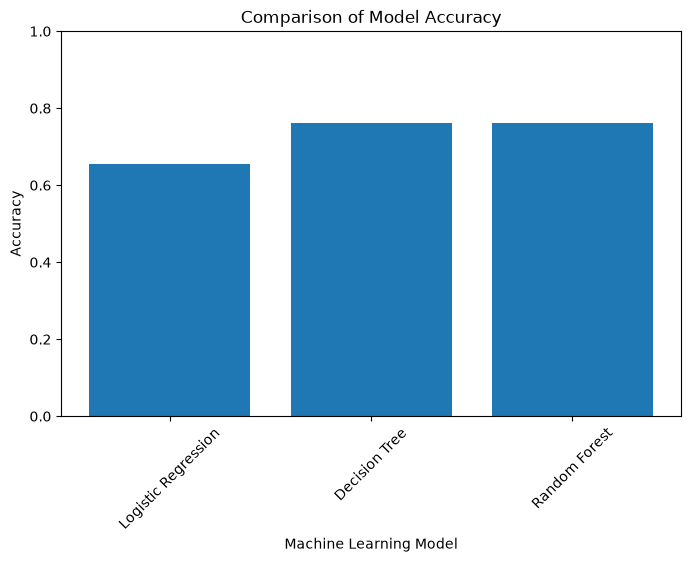

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Machine Learning Model")

plt.ylabel("Accuracy")

plt.title("Comparison of Model Accuracy")

plt.ylim(0,1)

plt.xticks(rotation=45)

plt.show()

Feature Importance:


,Feature,Importance
1,stop_lat,0.579246
2,stop_lon,0.388894
4,route_type,0.020976
0,departure_hour,0.009195
3,direction_id,0.001688


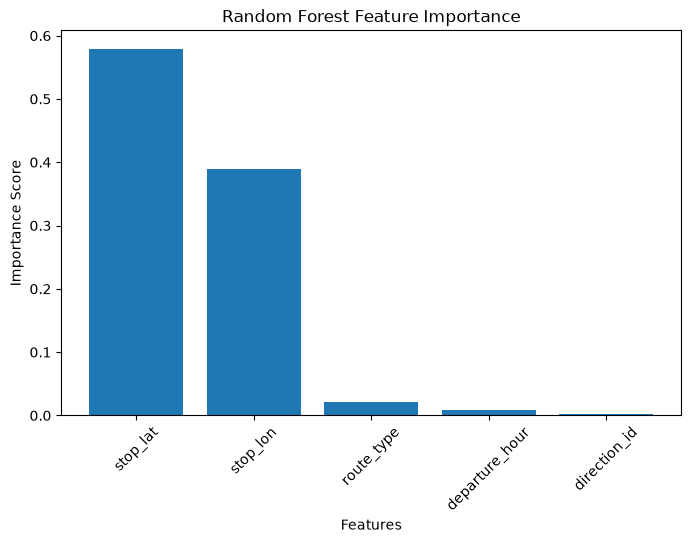

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = [
    "departure_hour",
    "stop_lat",
    "stop_lon",
    "direction_id",
    "route_type"
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.featureImportances.toArray()
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")

display(importance_df)

plt.figure(figsize=(8,5))

plt.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.show()

In [40]:
print("Final Model Comparison")

print("--------------------------------")

print("Logistic Regression Accuracy :", lr_accuracy)

print("Decision Tree Accuracy       :", dt_accuracy)

print("Random Forest Accuracy       :", rf_accuracy)

print("--------------------------------")

print("Best Model: Random Forest")

Final Model Comparison
--------------------------------
Logistic Regression Accuracy : 0.6541555495598126
Decision Tree Accuracy       : 0.7622488033496218
Random Forest Accuracy       : 0.7608697824544574
--------------------------------
Best Model: Random Forest


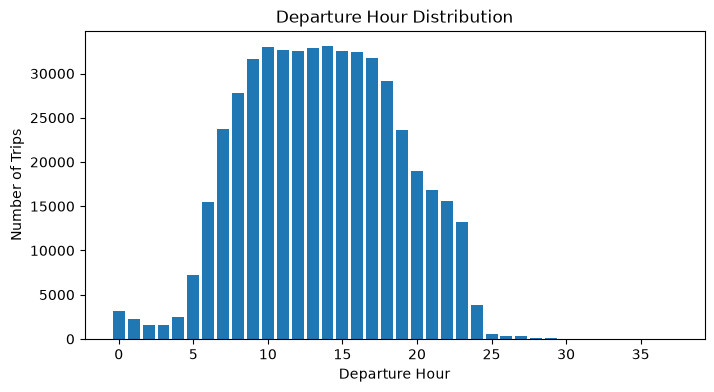

In [43]:
hour_df = data.groupBy("departure_hour").count().orderBy("departure_hour").toPandas()

plt.figure(figsize=(8,4))
plt.bar(hour_df["departure_hour"], hour_df["count"])
plt.xlabel("Departure Hour")
plt.ylabel("Number of Trips")
plt.title("Departure Hour Distribution")
plt.show()

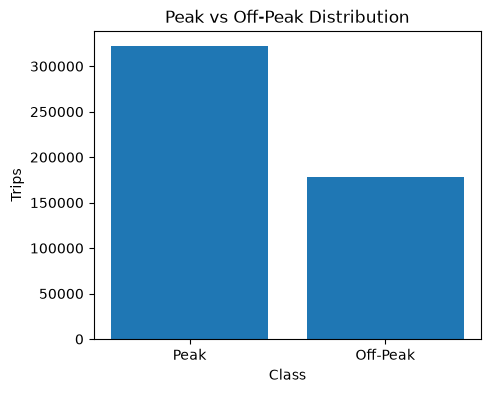

In [44]:
label_df = data.groupBy("label").count().toPandas()

label_df["Class"] = label_df["label"].map({
    0: "Off-Peak",
    1: "Peak"
})

plt.figure(figsize=(5,4))
plt.bar(label_df["Class"], label_df["count"])
plt.xlabel("Class")
plt.ylabel("Trips")
plt.title("Peak vs Off-Peak Distribution")
plt.show()

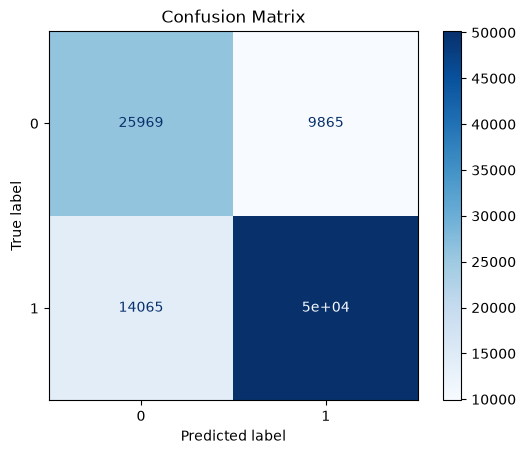

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_predictions = rf_model.transform(test_data)

y_true = rf_predictions.select("label").toPandas()["label"]
y_pred = rf_predictions.select("prediction").toPandas()["prediction"]

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [41]:
print("Spark UI:")

print(spark.sparkContext.uiWebUrl)

Spark UI:
http://DESKTOP-7N2BB1C:4041


In [47]:
ml_data.toPandas().to_csv(
    "final_dataset.csv",
    index=False
)

import os

print("Current Working Directory:")

print(os.getcwd())

print("\nFiles in Directory:")

print(os.listdir())

Current Working Directory:
C:\Users\Dell

Files in Directory:
['.android', '.bash_history', '.config', '.copilot', '.emulator_console_auth_token', '.git', '.gitconfig', '.gradle', '.ipynb_checkpoints', '.ipython', '.javacpp', '.jupyter', '.lesshst', '.local', '.m2', '.matplotlib', '.nbi', '.scala_history', '.scala_history_jline3', '.ssh', '.streamlit', '.thumbnails', '.THypervBox', '.viminfo', '.vscode', '.vscode-shared', '3D Objects', 'AndroidStudioProjects', 'AppData', 'Application Data', 'battery-report.html', 'Clustering.ipynb', 'Contacts', 'Cookies', 'data prepossing .ipynb', 'Data Preprocessing lab session.ipynb', 'data preprocessing.ipynb', 'Data Science_lab1a.ipynb', 'datascience_lab1b.ipynb', 'Documents', 'Downloads', 'Favorites', 'final_dataset.csv', 'hs_err_pid25904.log', 'import heart1.py', 'IntelGraphicsProfiles', 'iris_clustering_results.csv', 'Links', 'Local Settings', 'Logistic regression.ipynb', 'ML_Predictive model.ipynb', 'model_results.csv', 'Music', 'My Documents',